# Power Normal Distribution

The **Power Normal distribution** is a generalisation of the Normal distribution through a power (Box-Cox-like) transformation. When the shape parameter p=1, it reduces to the standard Normal. It provides additional flexibility to model skewed data that is "close to" Normal.

| Property | Value |
|---|---|
| **Parameters** | p (shape/power, p > 0), μ (location), σ (scale) |
| **PDF** | f(x) = p · φ(z) · [Φ(z)]^(p−1) / σ, where z=(x−μ)/σ |
| **CDF** | F(x) = [Φ(z)]^p |
| **Special case** | p=1 → Standard Normal |
| **Shape effect** | p < 1: right-skewed; p = 1: Normal; p > 1: left-skewed |
| **Use cases** | Reliability analysis; alternative to Box-Cox transform |
| **Note** | Not widely supported in standard software — use scipy `powernorm` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

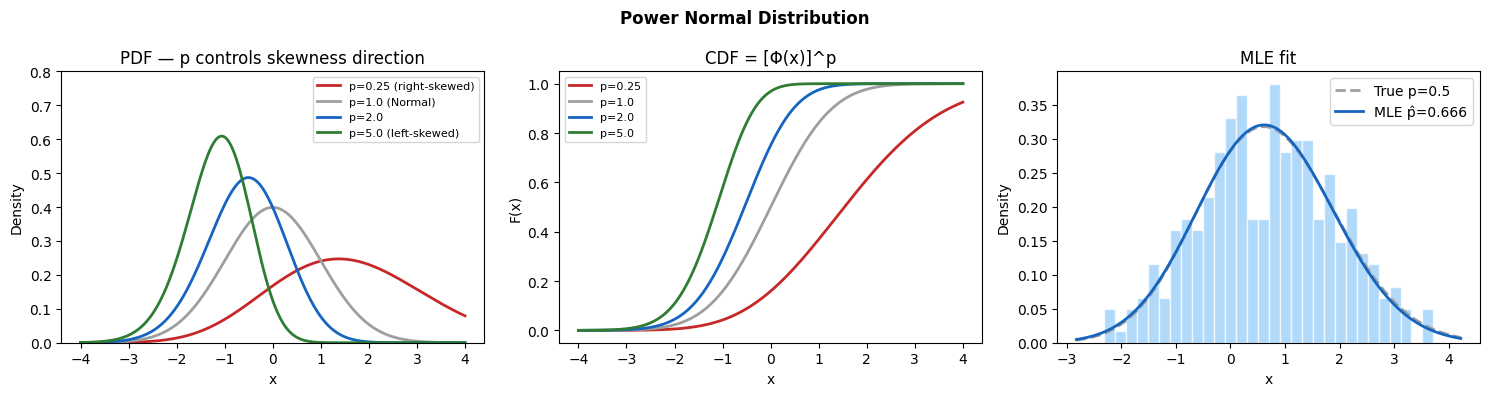

True p=0.5, MLE p̂=0.666
Skewness: true=0.137, sample=0.015


In [2]:
# scipy powernorm: c=p (shape parameter)
x = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Power Normal Distribution', fontsize=12, fontweight='bold')

# PDF
for p, color, label in [(0.25, '#C62828', 'p=0.25 (right-skewed)'),
                         (1.0,  '#9E9E9E', 'p=1.0 (Normal)'),
                         (2.0,  '#1565C0', 'p=2.0'),
                         (5.0,  '#2E7D32', 'p=5.0 (left-skewed)')]:
    axes[0].plot(x, stats.powernorm(c=p).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — p controls skewness direction')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=8)

# CDF
for p, color, label in [(0.25, '#C62828', 'p=0.25'), (1.0, '#9E9E9E', 'p=1.0'),
                         (2.0, '#1565C0', 'p=2.0'), (5.0, '#2E7D32', 'p=5.0')]:
    axes[1].plot(x, stats.powernorm(c=p).cdf(x), color=color, linewidth=2, label=label)
axes[1].set_title('CDF = [Φ(x)]^p')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# MLE fit to skewed data
np.random.seed(42)
true_p = 0.5
sample = stats.powernorm(c=true_p).rvs(300)
p_fit, loc_fit, scale_fit = stats.powernorm.fit(sample)
x_fit = np.linspace(sample.min()-0.5, sample.max()+0.5, 300)

axes[2].hist(sample, bins=30, density=True, color='#90CAF9', edgecolor='white', alpha=0.7)
axes[2].plot(x_fit, stats.powernorm(c=true_p).pdf(x_fit),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True p={true_p}')
axes[2].plot(x_fit, stats.powernorm(c=p_fit, loc=loc_fit, scale=scale_fit).pdf(x_fit),
             color='#1565C0', linewidth=2, label=f'MLE p̂={p_fit:.3f}')
axes[2].set_title('MLE fit')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"True p={true_p}, MLE p̂={p_fit:.3f}")
print(f"Skewness: true={stats.powernorm(c=true_p).stats('s'):.3f}, "
      f"sample={stats.skew(sample):.3f}")

## Key Takeaways

| | |
|---|---|
| **p=1** | Reduces to standard Normal |
| **p < 1** | Right-skewed — tail extends to the right |
| **p > 1** | Left-skewed — distribution shifts left |
| **CDF formula** | F(x) = Φ(x)^p — elegant power of the Normal CDF |
| **Hazard** | Monotonically increasing for all p — suitable for wear-out reliability |
| **Alternative** | Box-Cox transformation is often preferred (more interpretable parameter) |
| **Software** | scipy `powernorm`; not in R base or Excel |